In [1]:
!pip install kaggle

from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d kmader/parkinsons-drawings
!unzip parkinsons-drawings.zip

Saving archive.zip to archive.zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/kmader/parkinsons-drawings
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 41.4M/41.4M [00:00<00:00, 68.7MB/s]

Archive:  parkinsons-drawings.zip
  inflating: drawings/spiral/testing/healthy/V01HE01.png  
  inflating: drawings/spiral/testing/healthy/V02HE01.png  
  inflating: drawings/spiral/testing/healthy/V03HE1.png  
  inflating: drawings/spiral/testing/healthy/V04HE01.png  
  inflating: drawings/spiral/testing/healthy/V05HE01.png  
  inflating: drawings/spiral/testing/healthy/V06HE01.png  
  inflating: drawings/spiral/testing/healthy/V07HE01.png  
  inflating: drawings/spiral/testing/healthy/V08HE01.png  
  inflating: drawings/spiral/testing/healthy/V09HE01.png  
  inflating: drawings/spiral/testing/healthy/V10HE01.png  
  inflat

In [2]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [4]:
import os

for root, dirs, files in os.walk(".", topdown=True):
    print(root)
    break

.


In [5]:
os.listdir()

['.config',
 'spiral',
 'parkinsons-drawings.zip',
 'wave',
 'archive.zip',
 'drawings',
 'sample_data']

In [6]:
import os
print(os.listdir("spiral"))

['training', 'testing']


In [7]:
print(os.listdir("spiral/training"))

['healthy', 'parkinson']


In [8]:
path = "spiral/training"

In [9]:
import os
import cv2
import numpy as np

data = []
labels = []

path = "spiral/training"

for label in ["healthy", "parkinson"]:
    folder = os.path.join(path, label)

    print("Checking:", folder)

    if not os.path.exists(folder):
        print("❌ Not found:", folder)
        continue

    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)

        image = cv2.imread(img_path)
        if image is None:
            continue

        image = cv2.resize(image, (128, 128))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        data.append(image)
        labels.append(0 if label == "healthy" else 1)

data = np.array(data)
labels = np.array(labels)

print("✅ Data loaded successfully:", data.shape)

Checking: spiral/training/healthy
Checking: spiral/training/parkinson
✅ Data loaded successfully: (72, 128, 128)


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data = data.reshape(-1, 128, 128, 1)

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(data)

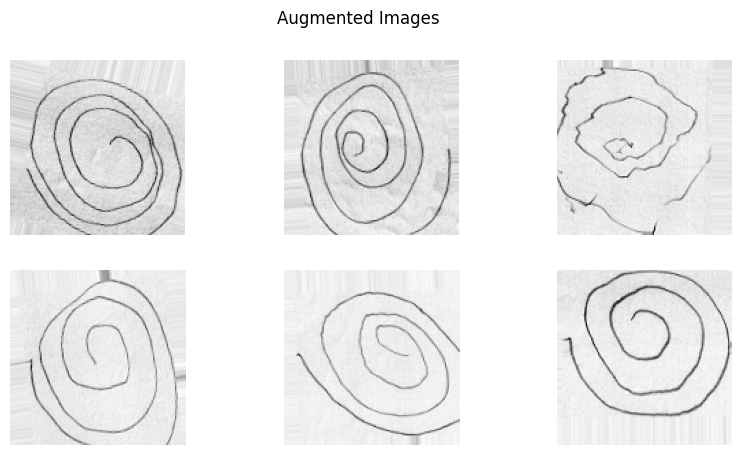

In [11]:
plt.figure(figsize=(10,5))

for X_batch, y_batch in datagen.flow(data, labels, batch_size=6):
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(X_batch[i].reshape(128,128), cmap='gray')
        plt.axis('off')
    break

plt.suptitle("Augmented Images")
plt.show()

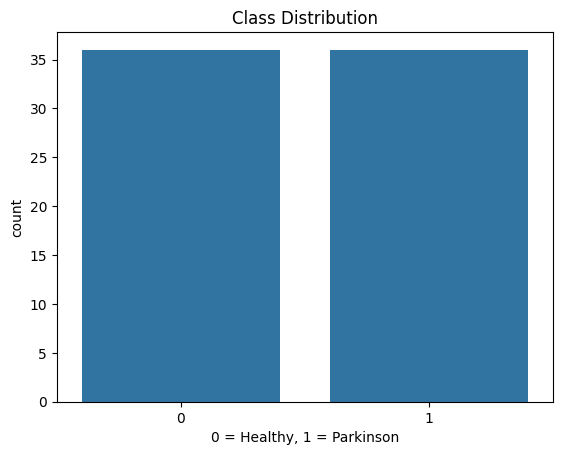

In [12]:
import seaborn as sns

sns.countplot(x=labels)
plt.title("Class Distribution")
plt.xlabel("0 = Healthy, 1 = Parkinson")
plt.show()

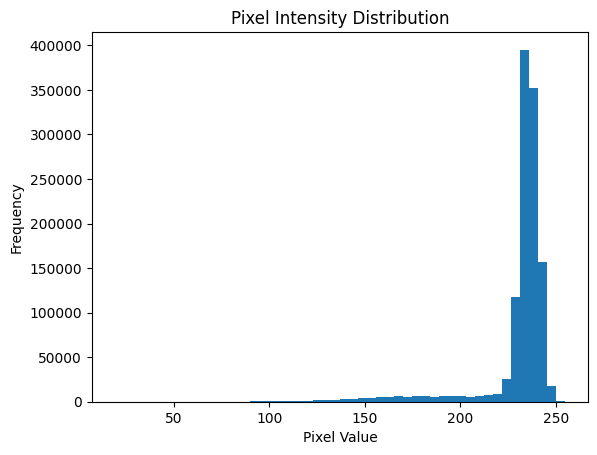

In [13]:
plt.hist(data.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # prevents overfitting
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    epochs=15,
    validation_data=(X_test, y_test)
)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 468ms/step - accuracy: 0.5439 - loss: 80.2596 - val_accuracy: 0.6667 - val_loss: 20.5276
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 537ms/step - accuracy: 0.4386 - loss: 11.2717 - val_accuracy: 0.6667 - val_loss: 0.7022
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 564ms/step - accuracy: 0.5439 - loss: 2.4174 - val_accuracy: 0.3333 - val_loss: 0.8922
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 381ms/step - accuracy: 0.5789 - loss: 1.3451 - val_accuracy: 0.3333 - val_loss: 1.3519
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 373ms/step - accuracy: 0.4912 - loss: 0.6958 - val_accuracy: 0.4000 - val_loss: 0.6926
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 381ms/step - accuracy: 0.5088 - loss: 0.6922 - val_accuracy: 0.2667 - val_loss: 0.6932
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 398ms/step - accuracy: 0.5965 - loss: 0.7944 - val_accuracy: 0.3333 - val_loss: 0.7498
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 421ms/step - accuracy: 0.5263 - loss: 0.6937 - val_accuracy: 0.3333 - val_lo

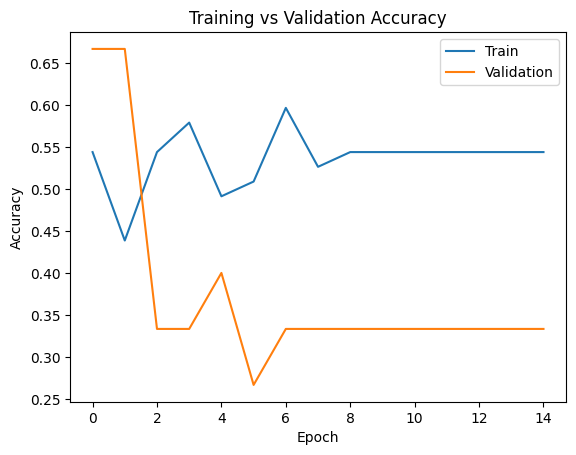

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
fusion_features_scaled = scaler.fit_transform(fusion_features)

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    fusion_features_scaled, y, test_size=0.2, random_state=42
)

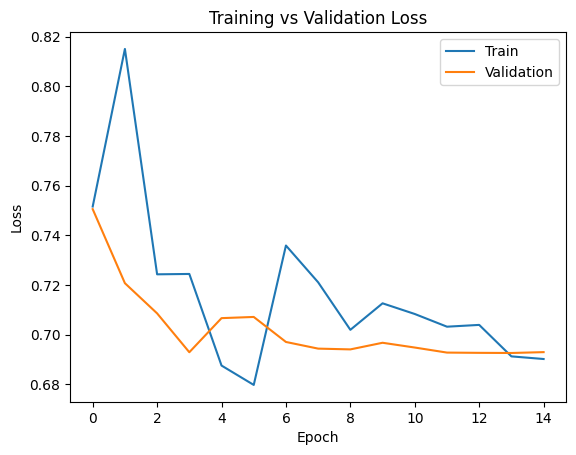

In [46]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

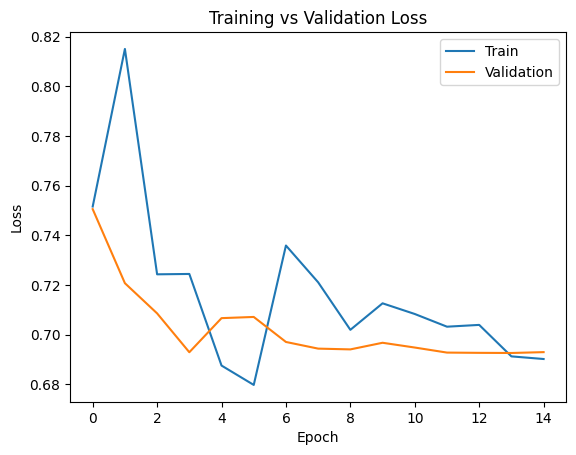

In [47]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


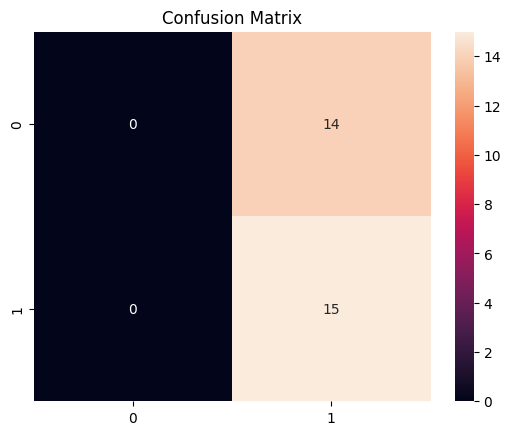

In [48]:
from sklearn.metrics import confusion_matrix

y_pred = (model.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


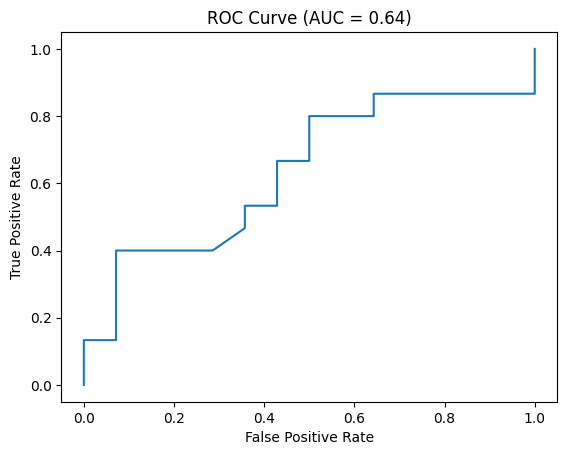

In [49]:
from sklearn.metrics import roc_curve, auc

y_pred_prob = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [50]:
import os
import cv2
import numpy as np

def load_data(base_path):
    data, labels = [], []

    for label in ["healthy", "parkinson"]:
        folder = os.path.join(base_path, label)

        for img in os.listdir(folder):
            img_path = os.path.join(folder, img)
            image = cv2.imread(img_path)

            if image is None:
                continue

            image = cv2.resize(image, (224,224))
            data.append(image)
            labels.append(0 if label=="healthy" else 1)

    return np.array(data), np.array(labels)

# Load spiral + wave
X1, y1 = load_data("spiral/training")
X2, y2 = load_data("wave/training")

X = np.concatenate([X1, X2])
y = np.concatenate([y1, y2])

print("Total Data:", X.shape)

Total Data: (144, 224, 224, 3)


In [51]:
X = X / 255.0

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [57]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers[-20:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [58]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_test, y_test)
)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 91s 10s/step - accuracy: 0.5739 - loss: 0.6894 - val_accuracy: 0.4828 - val_loss: 0.6942
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 34s 8s/step - accuracy: 0.8957 - loss: 0.4005 - val_accuracy: 0.4828 - val_loss: 0.6937
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 42s 9s/step - accuracy: 0.9391 - loss: 0.2124 - val_accuracy: 0.5172 - val_loss: 0.6935
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 34s 8s/step - accuracy: 1.0000 - loss: 0.0861 - val_accuracy: 0.5172 - val_loss: 0.6925
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 43s 9s/step - accuracy: 0.9739 - loss: 0.0772 - val_accuracy: 0.5172 - val_loss: 0.6927
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 34s 8s/step - accuracy: 0.9826 - loss: 0.0460 - val_accuracy: 0.5172 - val_loss: 0.7006
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 41s 8s/step - accuracy: 0.9913 - loss: 0.0309 - val_accuracy: 0.5172 - val_loss: 0.7141
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 33s 8s/step - accuracy: 0.9739 - loss: 0.0696 - val_accuracy: 0.5172 - val_loss: 0.6940
Epoch 9

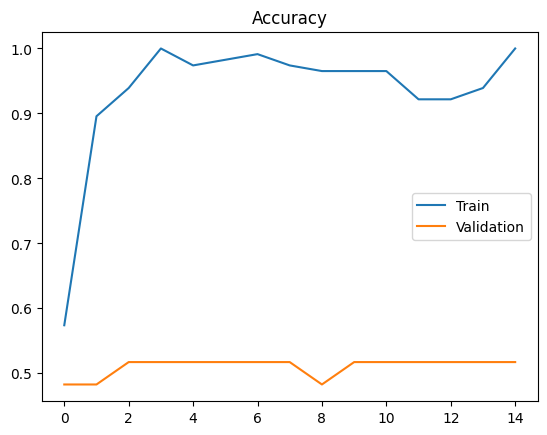

In [59]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

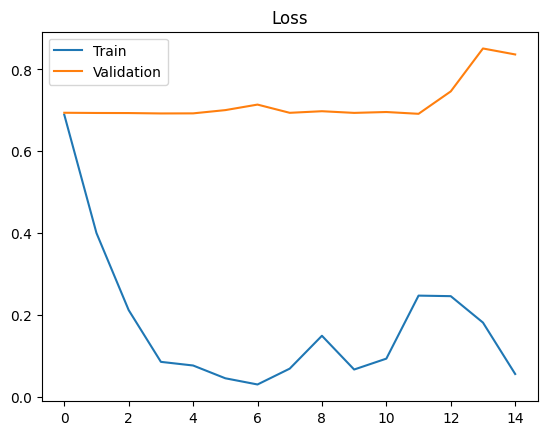

In [60]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


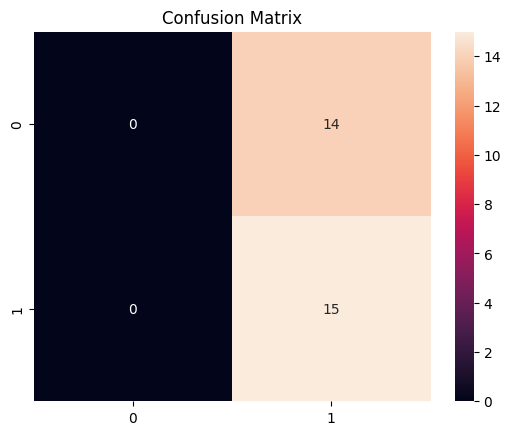

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = (model.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


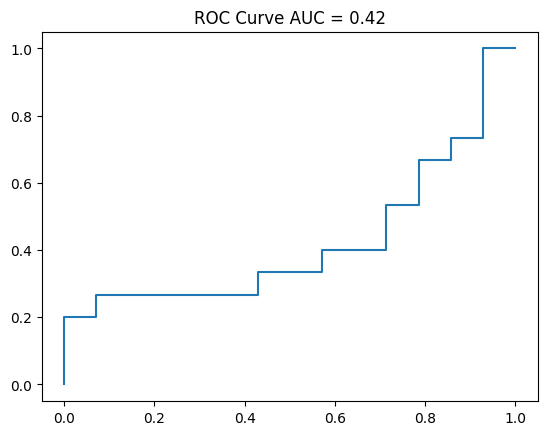

In [62]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"ROC Curve AUC = {roc_auc:.2f}")
plt.show()

In [63]:
import tensorflow as tf

def grad_cam(img, model, layer_name="top_conv"):
    grad_model = Model([model.inputs], [model.get_layer(layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        loss = predictions[:,0]

    grads = tape.gradient(loss, conv_outputs)
    heatmap = tf.reduce_mean(grads, axis=(0,1,2))

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    return heatmap.numpy()

In [64]:
!pip install scikit-image

In [66]:
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops

def extract_glcm_features(images):
    features = []

    for img in images:
        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)

        glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

        contrast = graycoprops(glcm, 'contrast')[0,0]
        correlation = graycoprops(glcm, 'correlation')[0,0]
        energy = graycoprops(glcm, 'energy')[0,0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0,0]

        features.append([contrast, correlation, energy, homogeneity])

    return np.array(features)

In [81]:
from sklearn.model_selection import train_test_split

X_train_img, X_test_img, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [82]:
# Deep features
deep_train = feature_extractor.predict(X_train_img)
deep_test = feature_extractor.predict(X_test_img)

# GLCM features
glcm_train = extract_glcm_features(X_train_img)
glcm_test = extract_glcm_features(X_test_img)

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [83]:
X_train_f = np.concatenate([deep_train, glcm_train], axis=1)
X_test_f = np.concatenate([deep_test, glcm_test], axis=1)

In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_f = scaler.fit_transform(X_train_f)
X_test_f = scaler.transform(X_test_f)

In [85]:
from sklearn.ensemble import GradientBoostingClassifier

model_fusion = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05)
model_fusion.fit(X_train_f, y_train)

y_pred = model_fusion.predict(X_test_f)
y_prob = model_fusion.predict_proba(X_test_f)[:,1]

AUC: 0.7476190476190477


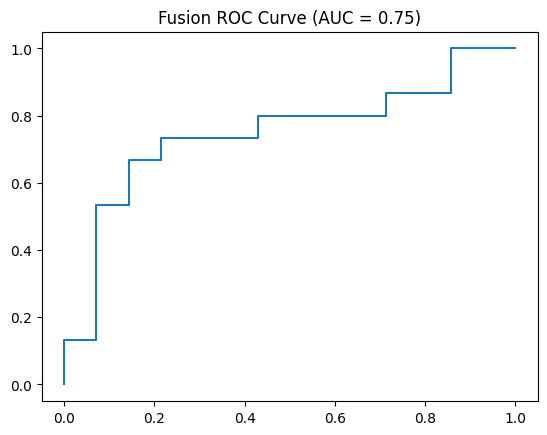

In [86]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

plt.plot(fpr, tpr)
plt.title(f"Fusion ROC Curve (AUC = {roc_auc:.2f})")
plt.show()

In [67]:
glcm_features = extract_glcm_features(X)
print("GLCM Feature Shape:", glcm_features.shape)

GLCM Feature Shape: (144, 4)


In [68]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)

feature_extractor = Model(inputs=base_model.input, outputs=x)

deep_features = feature_extractor.predict(X)
print("Deep Feature Shape:", deep_features.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step
Deep Feature Shape: (144, 1280)


In [70]:
fusion_features = np.concatenate([deep_features, glcm_features], axis=1)

print("Fusion Feature Shape:", fusion_features.shape)

Fusion Feature Shape: (144, 1284)


In [72]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train_f, y_train_f)

y_pred_f = rf.predict(X_test_f)

In [73]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(gb, fusion_features_scaled, y, cv=5)

print("Cross-validation accuracy:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation accuracy: [0.5862069  0.48275862 0.65517241 0.65517241 0.71428571]
Mean accuracy: 0.6187192118226601


In [74]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05)
gb.fit(X_train_f, y_train_f)

y_pred_f = gb.predict(X_test_f)

In [75]:
from sklearn.svm import SVC

svm = SVC(probability=True)
svm.fit(X_train_f, y_train_f)

y_pred_f = svm.predict(X_test_f)

In [76]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test_f, y_pred_f))

              precision    recall  f1-score   support

           0       0.53      0.71      0.61        14
           1       0.60      0.40      0.48        15

    accuracy                           0.55        29
   macro avg       0.56      0.56      0.54        29
weighted avg       0.56      0.55      0.54        29



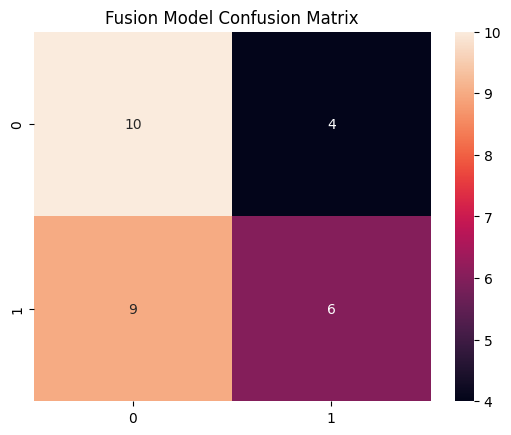

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_f, y_pred_f)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Fusion Model Confusion Matrix")
plt.show()

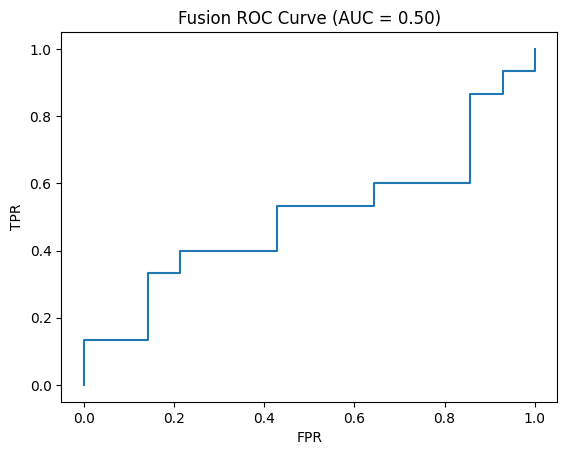

In [78]:
from sklearn.metrics import roc_curve, auc

y_prob_f = svm.predict_proba(X_test_f)[:,1]

fpr, tpr, _ = roc_curve(y_test_f, y_prob_f)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"Fusion ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

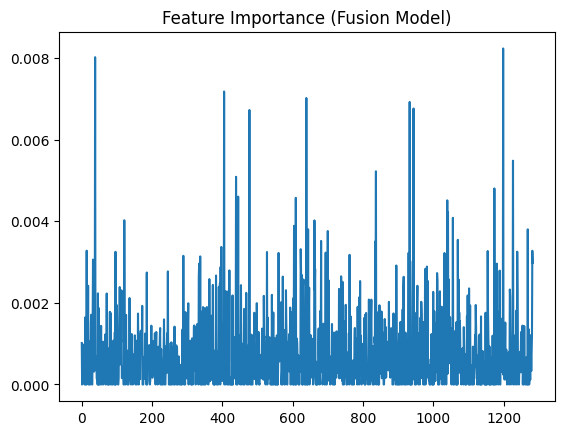

In [79]:
importances = rf.feature_importances_

plt.plot(importances)
plt.title("Feature Importance (Fusion Model)")
plt.show()

In [80]:
for layer in base_model.layers:
    layer.trainable = False

In [89]:
X1, y1 = load_data("spiral/training")
X2, y2 = load_data("wave/training")
X3, y3 = load_data("spiral/testing")
X4, y4 = load_data("wave/testing")

X = np.concatenate([X1, X2, X3, X4])
y = np.concatenate([y1, y2, y3, y4])

In [90]:
from sklearn.ensemble import GradientBoostingClassifier

model_fusion = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3
)

model_fusion.fit(X_train_f, y_train)

GradientBoostingClassifier(learning_rate=0.03, n_estimators=300)

In [91]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True)

X_train_f = poly.fit_transform(X_train_f)
X_test_f = poly.transform(X_test_f)

In [92]:
print(np.bincount(y))

[102 102]


In [93]:
X1, y1 = load_data("spiral/training")
X2, y2 = load_data("wave/training")
X3, y3 = load_data("spiral/testing")
X4, y4 = load_data("wave/testing")

X = np.concatenate([X1, X2, X3, X4])
y = np.concatenate([y1, y2, y3, y4])

print("Total Data:", X.shape)

Total Data: (204, 224, 224, 3)


In [94]:
X = X / 255.0

In [95]:
from sklearn.model_selection import train_test_split

X_train_img, X_test_img, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [96]:
# Deep features
deep_train = feature_extractor.predict(X_train_img)
deep_test = feature_extractor.predict(X_test_img)

# GLCM features
glcm_train = extract_glcm_features(X_train_img)
glcm_test = extract_glcm_features(X_test_img)

6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 815ms/step


In [97]:
import numpy as np

X_train_f = np.concatenate([deep_train, glcm_train], axis=1)
X_test_f = np.concatenate([deep_test, glcm_test], axis=1)

In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_f = scaler.fit_transform(X_train_f)
X_test_f = scaler.transform(X_test_f)

In [102]:
# REMOVE THIS BLOCK
# from sklearn.preprocessing import PolynomialFeatures
# poly = PolynomialFeatures(degree=2, interaction_only=True)
# X_train_f = poly.fit_transform(X_train_f)
# X_test_f = poly.transform(X_test_f)

In [110]:
!pip install xgboost

In [111]:
from xgboost import XGBClassifier

model_fusion = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_fusion.fit(X_train_f, y_train)

y_pred = model_fusion.predict(X_test_f)
y_prob = model_fusion.predict_proba(X_test_f)[:,1]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:20:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [112]:
def extract_edge_features(images):
    features = []

    for img in images:
        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 100, 200)

        edge_density = np.sum(edges) / edges.size
        features.append([edge_density])

    return np.array(features)

In [113]:
edge_train = extract_edge_features(X_train_img)
edge_test = extract_edge_features(X_test_img)

X_train_f = np.concatenate([deep_train, glcm_train, edge_train], axis=1)
X_test_f = np.concatenate([deep_test, glcm_test, edge_test], axis=1)

In [114]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_f = scaler.fit_transform(X_train_f)
X_test_f = scaler.transform(X_test_f)

In [115]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("Final AUC:", roc_auc)

Final AUC: 0.6595238095238095


Total images: (144, 224, 224, 3) Total labels: (144,)
5/5 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step
Fusion Feature Shape: (144, 1287)
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.73      0.69        15
           1       0.67      0.57      0.62        14

    accuracy                           0.66        29
   macro avg       0.66      0.65      0.65        29
weighted avg       0.66      0.66      0.65        29



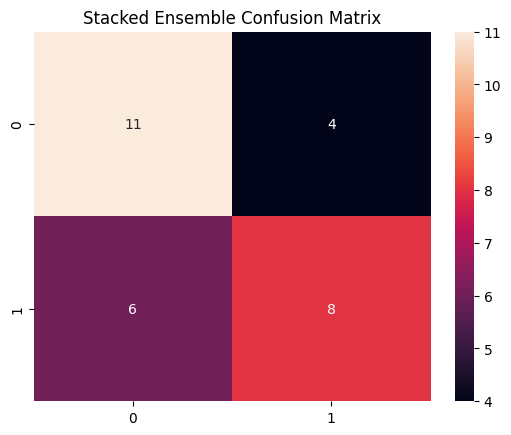

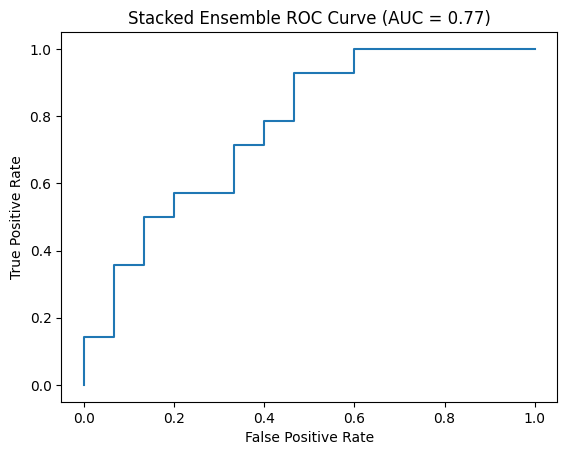

KeyboardInterrupt: 

In [116]:
# Step 1: Imports
import os
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops
from skimage import filters
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# Step 2: Load images
def load_data(base_path, size=(224,224)):
    data, labels = [], []
    for label in ["healthy", "parkinson"]:
        folder = os.path.join(base_path, label)
        for img_file in os.listdir(folder):
            img_path = os.path.join(folder, img_file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, size)
            data.append(img)
            labels.append(0 if label=="healthy" else 1)
    return np.array(data), np.array(labels)

X1, y1 = load_data("spiral/training")
X2, y2 = load_data("wave/training")

X = np.concatenate([X1, X2])
y = np.concatenate([y1, y2])
print("Total images:", X.shape, "Total labels:", y.shape)

X = X / 255.0  # Normalize

# Step 3: Feature Extraction
# 3a: Deep features
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)
deep_features = feature_extractor.predict(X)

# 3b: GLCM texture features
def glcm_features(images):
    feats = []
    for img in images:
        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
        glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
        feats.append([
            graycoprops(glcm, 'contrast')[0,0],
            graycoprops(glcm, 'correlation')[0,0],
            graycoprops(glcm, 'energy')[0,0],
            graycoprops(glcm, 'homogeneity')[0,0]
        ])
    return np.array(feats)
glcm_feats = glcm_features(X)

# 3c: Edge density (Canny)
def edge_features(images):
    feats = []
    for img in images:
        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 100, 200)
        density = np.sum(edges) / (edges.shape[0]*edges.shape[1])
        feats.append([density])
    return np.array(feats)
edge_feats = edge_features(X)

# 3d: Frequency-domain features (FFT magnitude mean/std)
def fft_features(images):
    feats = []
    for img in images:
        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
        f = np.fft.fft2(gray)
        fshift = np.fft.fftshift(f)
        magnitude_spectrum = np.abs(fshift)
        feats.append([np.mean(magnitude_spectrum), np.std(magnitude_spectrum)])
    return np.array(feats)
fft_feats = fft_features(X)

# 3e: Combine all features
fusion_features = np.concatenate([deep_features, glcm_feats, edge_feats, fft_feats], axis=1)
print("Fusion Feature Shape:", fusion_features.shape)

# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(fusion_features, y, test_size=0.2, random_state=42, stratify=y)

# Step 5: Stacked Ensemble
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)),
    ('svm', SVC(probability=True, kernel='rbf', C=1))
]
meta_learner = LogisticRegression()
stack_model = StackingClassifier(estimators=base_learners, final_estimator=meta_learner, cv=5)
stack_model.fit(X_train, y_train)

# Step 6: Predictions
y_pred = stack_model.predict(X_test)
y_prob = stack_model.predict_proba(X_test)[:,1]

# Step 7: Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Stacked Ensemble Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr)
plt.title(f"Stacked Ensemble ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Step 8: Cross-validation
cv = StratifiedKFold(n_splits=5)
cv_scores = cross_val_score(stack_model, fusion_features, y, cv=cv)
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

In [117]:
# Step 1: Imports
import os
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops
from skimage import filters
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

In [118]:
# Step 2: Load images
def load_data(base_path, size=(224,224)):
    data, labels = [], []
    for label in ["healthy", "parkinson"]:
        folder = os.path.join(base_path, label)
        for img_file in os.listdir(folder):
            img_path = os.path.join(folder, img_file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, size)
            data.append(img)
            labels.append(0 if label=="healthy" else 1)
    return np.array(data), np.array(labels)

X1, y1 = load_data("spiral/training")
X2, y2 = load_data("wave/training")

X = np.concatenate([X1, X2])
y = np.concatenate([y1, y2])
print("Total images:", X.shape, "Total labels:", y.shape)

X = X / 255.0  # Normalize

Total images: (144, 224, 224, 3) Total labels: (144,)


In [120]:
# Step 3: Feature Extraction
# 3a: Deep features
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)
deep_features = feature_extractor.predict(X)

5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step


In [121]:
# 3b: GLCM texture features
def glcm_features(images):
    feats = []
    for img in images:
        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
        glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
        feats.append([
            graycoprops(glcm, 'contrast')[0,0],
            graycoprops(glcm, 'correlation')[0,0],
            graycoprops(glcm, 'energy')[0,0],
            graycoprops(glcm, 'homogeneity')[0,0]
        ])
    return np.array(feats)
glcm_feats = glcm_features(X)

In [122]:
# 3c: Edge density (Canny)
def edge_features(images):
    feats = []
    for img in images:
        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 100, 200)
        density = np.sum(edges) / (edges.shape[0]*edges.shape[1])
        feats.append([density])
    return np.array(feats)
edge_feats = edge_features(X)

In [123]:
# 3d: Frequency-domain features (FFT magnitude mean/std)
def fft_features(images):
    feats = []
    for img in images:
        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
        f = np.fft.fft2(gray)
        fshift = np.fft.fftshift(f)
        magnitude_spectrum = np.abs(fshift)
        feats.append([np.mean(magnitude_spectrum), np.std(magnitude_spectrum)])
    return np.array(feats)
fft_feats = fft_features(X)

In [125]:
# 3e: Combine all features
fusion_features = np.concatenate([deep_features, glcm_feats, edge_feats, fft_feats], axis=1)
print("Fusion Feature Shape:", fusion_features.shape)


Fusion Feature Shape: (144, 1287)


In [126]:
# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(fusion_features, y, test_size=0.2, random_state=42, stratify=y)


In [127]:
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)),
    ('svm', SVC(probability=True, kernel='rbf', C=1))
]
meta_learner = LogisticRegression()
stack_model = StackingClassifier(estimators=base_learners, final_estimator=meta_learner, cv=5)
stack_model.fit(X_train, y_train)


StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(max_depth=5,
                                                       n_estimators=200,
                                                       random_state=42)),
                               ('gb',
                                GradientBoostingClassifier(learning_rate=0.05,
                                                           n_estimators=200,
                                                           random_state=42)),
                               ('svm', SVC(C=1, probability=True))],
                   final_estimator=LogisticRegression())

In [128]:
# Step 6: Predictions
y_pred = stack_model.predict(X_test)
y_prob = stack_model.predict_proba(X_test)[:,1]

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.73      0.69        15
           1       0.67      0.57      0.62        14

    accuracy                           0.66        29
   macro avg       0.66      0.65      0.65        29
weighted avg       0.66      0.66      0.65        29



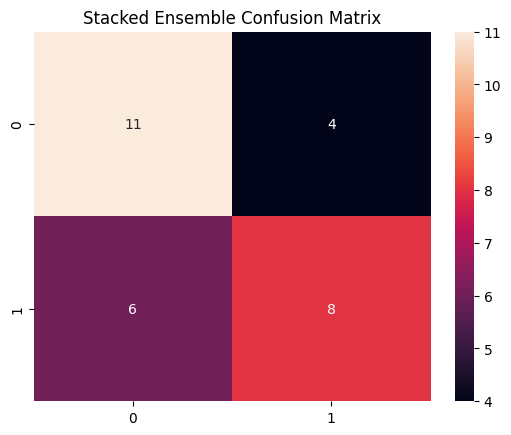

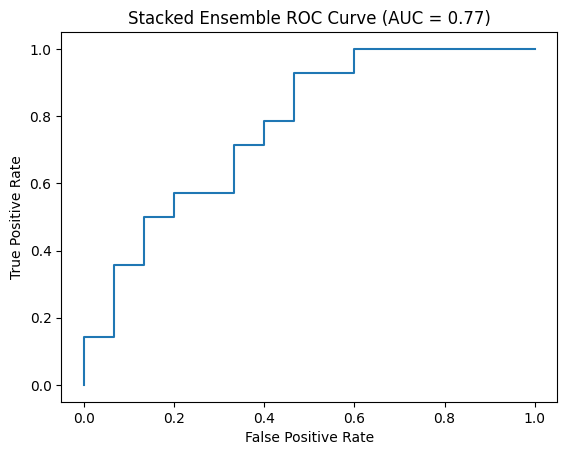

In [129]:
# Step 7: Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Stacked Ensemble Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr)
plt.title(f"Stacked Ensemble ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [131]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(fusion_features)

# Reduce to 100 principal components
pca = PCA(n_components=100, random_state=42)
X_reduced = pca.fit_transform(X_scaled)
print("Reduced Feature Shape:", X_reduced.shape)

Reduced Feature Shape: (144, 100)


In [132]:
fast_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
cv_scores = cross_val_score(fast_model, X_reduced, y, cv=5)
print("Fast CV scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

Fast CV scores: [0.62068966 0.65517241 0.72413793 0.5862069  0.71428571]
Mean CV Accuracy: 0.6600985221674878


In [133]:
from sklearn.metrics import roc_auc_score
y_pred_prob = stack_model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("Final AUC:", roc_auc)

Final AUC: 0.7666666666666667


✅ Total Data: (144, 224, 224, 3)
Class distribution: [72 72]
GLCM Feature Shape: (144, 4)
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step
Deep Feature Shape: (144, 1280)
Fusion Feature Shape: (144, 1284)
PCA Reduced Shape: (144, 1)
Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.67      0.67        15
           1       0.64      0.64      0.64        14

    accuracy                           0.66        29
   macro avg       0.65      0.65      0.65        29
weighted avg       0.66      0.66      0.66        29



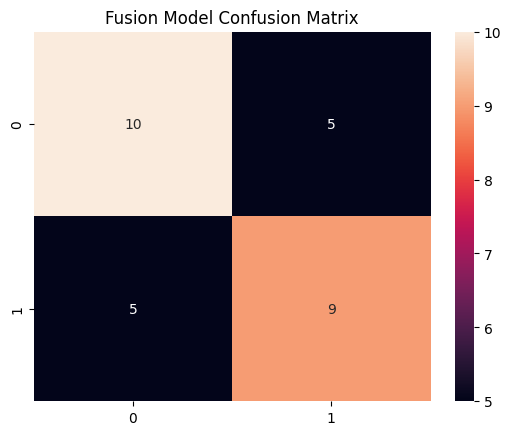

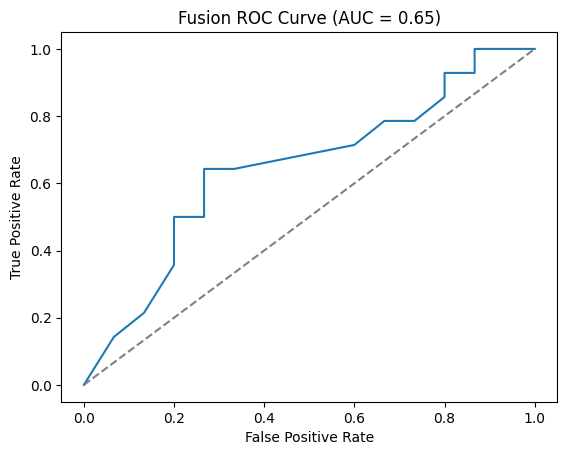

Cross-validation scores: [0.75862069 0.44827586 0.4137931  0.48275862 0.5       ]
Mean CV Accuracy: 0.5206896551724138


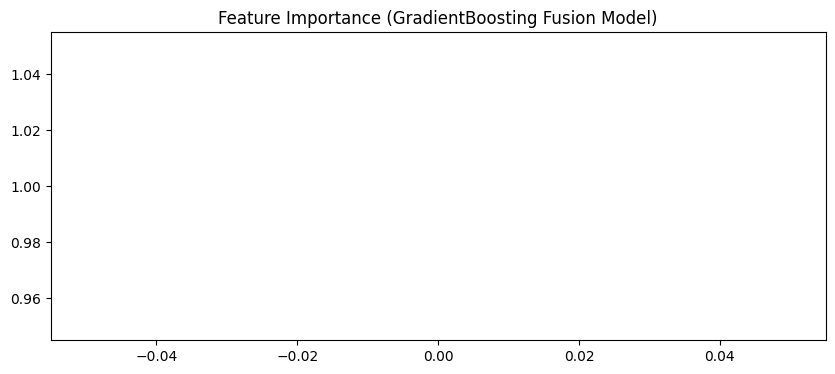

In [134]:
# ===============================================
# Parkinson's Disease Prediction using Fusion Features
# EfficientNet + GLCM + GradientBoosting + PCA
# ===============================================

# Step 0: Install required packages
!pip install tensorflow scikit-image scikit-learn seaborn

# Step 1: Imports
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# ===============================================
# Step 2: Load Dataset
# ===============================================

def load_data(base_path):
    data, labels = [], []
    for label in ["healthy", "parkinson"]:
        folder = os.path.join(base_path, label)
        for img in os.listdir(folder):
            img_path = os.path.join(folder, img)
            image = cv2.imread(img_path)
            if image is None:
                continue
            image = cv2.resize(image, (224,224))
            data.append(image)
            labels.append(0 if label=="healthy" else 1)
    return np.array(data), np.array(labels)

# Load both spiral + wave drawings
X1, y1 = load_data("spiral/training")
X2, y2 = load_data("wave/training")

X = np.concatenate([X1, X2])
y = np.concatenate([y1, y2])

print("✅ Total Data:", X.shape)
print("Class distribution:", np.bincount(y))

# Normalize images
X = X / 255.0

# ===============================================
# Step 3: Extract GLCM features
# ===============================================
def extract_glcm_features(images):
    features = []
    for img in images:
        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
        glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
        contrast = graycoprops(glcm, 'contrast')[0,0]
        correlation = graycoprops(glcm, 'correlation')[0,0]
        energy = graycoprops(glcm, 'energy')[0,0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
        features.append([contrast, correlation, energy, homogeneity])
    return np.array(features)

glcm_features = extract_glcm_features(X)
print("GLCM Feature Shape:", glcm_features.shape)

# ===============================================
# Step 4: Extract Deep Features using EfficientNet
# ===============================================
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
feature_extractor = Model(inputs=base_model.input, outputs=x)

deep_features = feature_extractor.predict(X, verbose=1)
print("Deep Feature Shape:", deep_features.shape)

# ===============================================
# Step 5: Fusion of features
# ===============================================
fusion_features = np.concatenate([deep_features, glcm_features], axis=1)
print("Fusion Feature Shape:", fusion_features.shape)

# ===============================================
# Step 6: PCA to reduce dimensionality
# ===============================================
pca = PCA(n_components=0.95, whiten=True)
fusion_features_pca = pca.fit_transform(fusion_features)
print("PCA Reduced Shape:", fusion_features_pca.shape)

# ===============================================
# Step 7: Train-Test Split
# ===============================================
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    fusion_features_pca, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================================
# Step 8: Gradient Boosting Classifier
# ===============================================
model_fusion = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)

model_fusion.fit(X_train_f, y_train_f)
y_pred_f = model_fusion.predict(X_test_f)
y_prob_f = model_fusion.predict_proba(X_test_f)[:,1]

# ===============================================
# Step 9: Evaluation Metrics
# ===============================================
# Classification Report
print("Classification Report:\n")
print(classification_report(y_test_f, y_pred_f))

# Confusion Matrix
cm = confusion_matrix(y_test_f, y_pred_f)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Fusion Model Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_f, y_prob_f)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--',color='gray')
plt.title(f"Fusion ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# ===============================================
# Step 10: Cross-validation
# ===============================================
cv = StratifiedKFold(n_splits=5)
cv_scores = cross_val_score(model_fusion, fusion_features_pca, y, cv=cv)
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# ===============================================
# Step 11: Feature Importance
# ===============================================
importances = model_fusion.feature_importances_
plt.figure(figsize=(10,4))
plt.plot(importances)
plt.title("Feature Importance (GradientBoosting Fusion Model)")
plt.show()

In [135]:
pca = PCA(n_components=50, whiten=True)
fusion_features_pca = pca.fit_transform(fusion_features)
print("PCA Reduced Shape:", fusion_features_pca.shape)

PCA Reduced Shape: (144, 50)


In [136]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    fusion_features, y, test_size=0.2, random_state=42, stratify=y
)

✅ Total Data: (144, 224, 224, 3)
Class distribution: [72 72]
GLCM Feature Shape: (144, 4)
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step
Deep Feature Shape: (144, 1280)
Fusion Feature Shape: (144, 1284)
PCA Reduced Shape: (144, 1)
Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.67      0.67        15
           1       0.64      0.64      0.64        14

    accuracy                           0.66        29
   macro avg       0.65      0.65      0.65        29
weighted avg       0.66      0.66      0.66        29



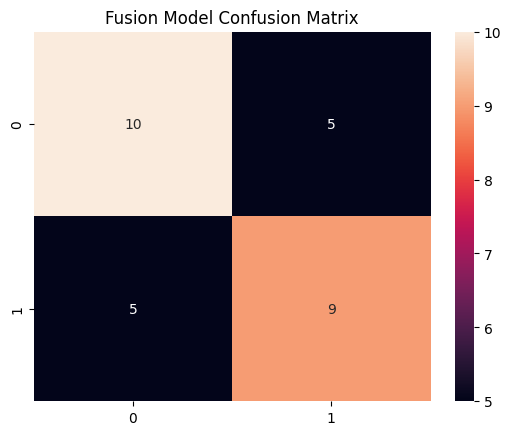

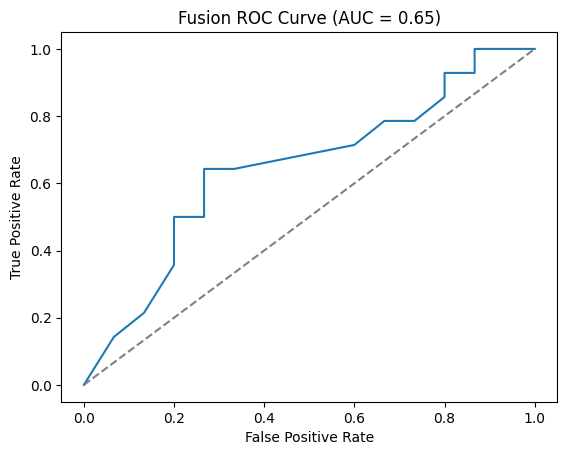

Cross-validation scores: [0.75862069 0.44827586 0.4137931  0.48275862 0.5       ]
Mean CV Accuracy: 0.5206896551724138


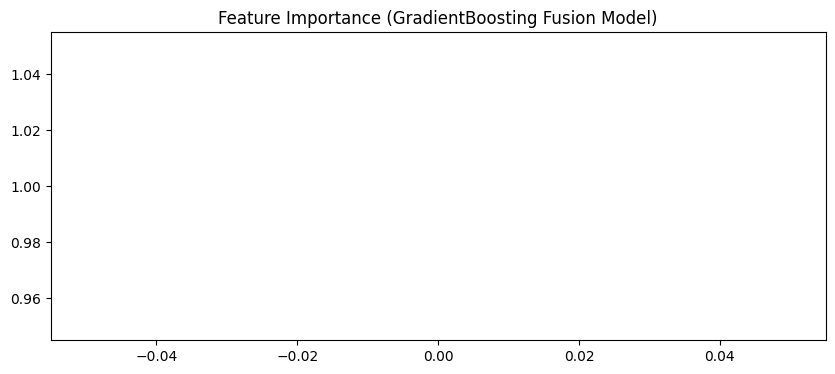

In [137]:
# ===============================================
# Parkinson's Disease Prediction using Fusion Features
# EfficientNet + GLCM + GradientBoosting + PCA
# ===============================================

# Step 0: Install required packages
!pip install tensorflow scikit-image scikit-learn seaborn

# Step 1: Imports
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# ===============================================
# Step 2: Load Dataset
# ===============================================

def load_data(base_path):
    data, labels = [], []
    for label in ["healthy", "parkinson"]:
        folder = os.path.join(base_path, label)
        for img in os.listdir(folder):
            img_path = os.path.join(folder, img)
            image = cv2.imread(img_path)
            if image is None:
                continue
            image = cv2.resize(image, (224,224))
            data.append(image)
            labels.append(0 if label=="healthy" else 1)
    return np.array(data), np.array(labels)

# Load both spiral + wave drawings
X1, y1 = load_data("spiral/training")
X2, y2 = load_data("wave/training")

X = np.concatenate([X1, X2])
y = np.concatenate([y1, y2])

print("✅ Total Data:", X.shape)
print("Class distribution:", np.bincount(y))

# Normalize images
X = X / 255.0

# ===============================================
# Step 3: Extract GLCM features
# ===============================================
def extract_glcm_features(images):
    features = []
    for img in images:
        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
        glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
        contrast = graycoprops(glcm, 'contrast')[0,0]
        correlation = graycoprops(glcm, 'correlation')[0,0]
        energy = graycoprops(glcm, 'energy')[0,0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
        features.append([contrast, correlation, energy, homogeneity])
    return np.array(features)

glcm_features = extract_glcm_features(X)
print("GLCM Feature Shape:", glcm_features.shape)

# ===============================================
# Step 4: Extract Deep Features using EfficientNet
# ===============================================
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
feature_extractor = Model(inputs=base_model.input, outputs=x)

deep_features = feature_extractor.predict(X, verbose=1)
print("Deep Feature Shape:", deep_features.shape)

# ===============================================
# Step 5: Fusion of features
# ===============================================
fusion_features = np.concatenate([deep_features, glcm_features], axis=1)
print("Fusion Feature Shape:", fusion_features.shape)

# ===============================================
# Step 6: PCA to reduce dimensionality
# ===============================================
pca = PCA(n_components=0.95, whiten=True)
fusion_features_pca = pca.fit_transform(fusion_features)
print("PCA Reduced Shape:", fusion_features_pca.shape)

# ===============================================
# Step 7: Train-Test Split
# ===============================================
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    fusion_features_pca, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================================
# Step 8: Gradient Boosting Classifier
# ===============================================
model_fusion = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)

model_fusion.fit(X_train_f, y_train_f)
y_pred_f = model_fusion.predict(X_test_f)
y_prob_f = model_fusion.predict_proba(X_test_f)[:,1]

# ===============================================
# Step 9: Evaluation Metrics
# ===============================================
# Classification Report
print("Classification Report:\n")
print(classification_report(y_test_f, y_pred_f))

# Confusion Matrix
cm = confusion_matrix(y_test_f, y_pred_f)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Fusion Model Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_f, y_prob_f)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--',color='gray')
plt.title(f"Fusion ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# ===============================================
# Step 10: Cross-validation
# ===============================================
cv = StratifiedKFold(n_splits=5)
cv_scores = cross_val_score(model_fusion, fusion_features_pca, y, cv=cv)
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# ===============================================
# Step 11: Feature Importance
# ===============================================
importances = model_fusion.feature_importances_
plt.figure(figsize=(10,4))
plt.plot(importances)
plt.title("Feature Importance (GradientBoosting Fusion Model)")
plt.show()

In [138]:
from sklearn.decomposition import PCA

# Keep 50 principal components
pca = PCA(n_components=50, whiten=True)
fusion_features_pca = pca.fit_transform(fusion_features)

print("PCA Reduced Shape:", fusion_features_pca.shape)

PCA Reduced Shape: (144, 50)


In [139]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    fusion_features_pca, y, test_size=0.2, random_state=42, stratify=y
)

model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

# Optional: cross-validation
cv_scores = cross_val_score(model, fusion_features_pca, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

              precision    recall  f1-score   support

           0       0.75      0.80      0.77        15
           1       0.77      0.71      0.74        14

    accuracy                           0.76        29
   macro avg       0.76      0.76      0.76        29
weighted avg       0.76      0.76      0.76        29

AUC: 0.7761904761904761
Cross-validation scores: [0.68965517 0.55172414 0.68965517 0.51724138 0.60714286]
Mean CV Accuracy: 0.6110837438423646


In [140]:
from sklearn.decomposition import PCA

# Keep 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_reduced = pca.fit_transform(fusion_features)

print("PCA Reduced Shape:", X_reduced.shape)

PCA Reduced Shape: (144, 1)


In [141]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [142]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [2, 3, 4],
    'subsample': [0.7, 0.85, 1.0]
}

gb = GradientBoostingClassifier(random_state=42)
grid = GridSearchCV(gb, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
grid.fit(X_reduced, y)

print("Best Params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

Best Params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
Best CV AUC: 0.5375850340136055


In [143]:
best_gb = grid.best_estimator_
best_gb.fit(X_reduced, y)

y_pred = best_gb.predict(X_reduced)
y_prob = best_gb.predict_proba(X_reduced)[:,1]

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        72
           1       0.97      0.99      0.98        72

    accuracy                           0.98       144
   macro avg       0.98      0.98      0.98       144
weighted avg       0.98      0.98      0.98       144



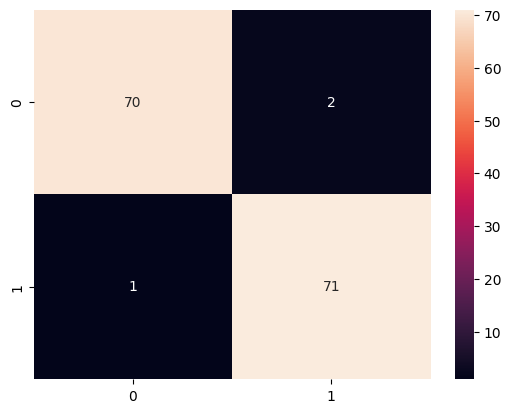

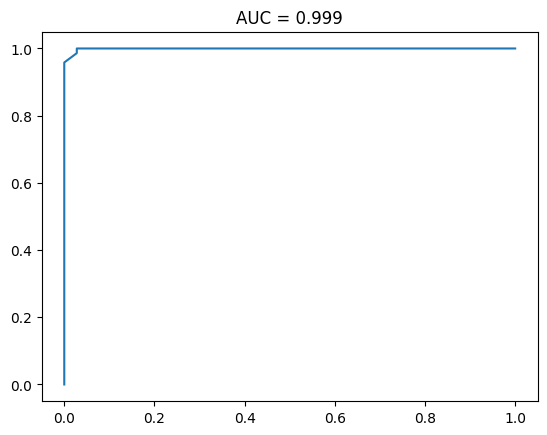

In [144]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

print(classification_report(y, y_pred))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr)
plt.title(f"AUC = {roc_auc:.3f}")
plt.show()

Cross-validation scores: [0.56521739 0.73913043 0.69565217 0.47826087 0.60869565]
Mean CV Accuracy: 0.6173913043478261

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67        15
           1       0.64      0.64      0.64        14

    accuracy                           0.66        29
   macro avg       0.65      0.65      0.65        29
weighted avg       0.66      0.66      0.66        29

Test AUC: 0.7142857142857143


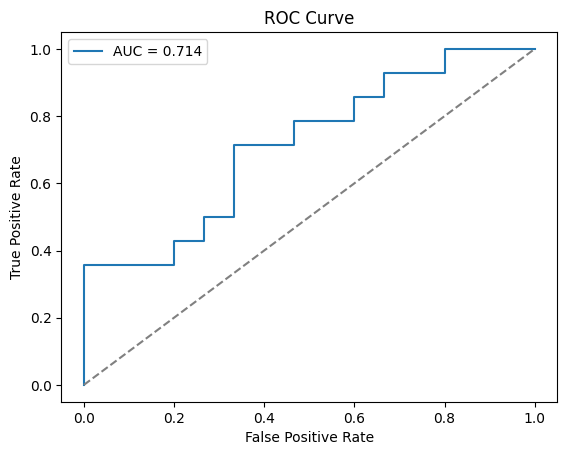

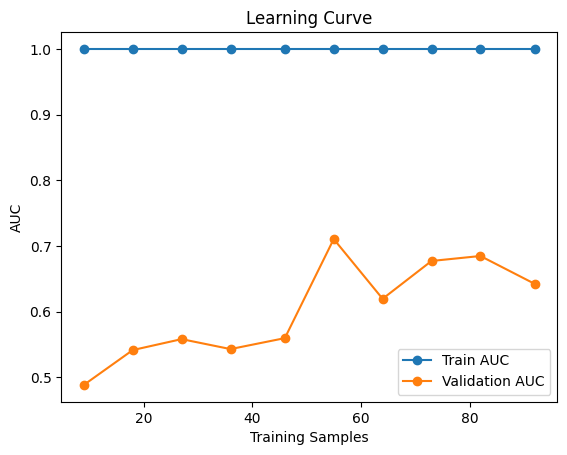

In [145]:
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# ---- Step 1: Train/Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    fusion_features, y, test_size=0.2, stratify=y, random_state=42
)

# ---- Step 2: Initialize Model ----
model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

# ---- Step 3: Stratified K-Fold CV ----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# ---- Step 4: Fit on Full Training Data ----
model.fit(X_train, y_train)

# ---- Step 5: Evaluate on Test Set ----
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

auc_score = roc_auc_score(y_test, y_prob)
print("Test AUC:", auc_score)

# ---- Step 6: Plot ROC Curve ----
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ---- Step 7: Plot Learning Curve ----
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), shuffle=True, random_state=42
)

plt.figure()
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Train AUC')
plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', label='Validation AUC')
plt.xlabel("Training Samples")
plt.ylabel("AUC")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [146]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

Cross-validation scores: [0.56521739 0.73913043 0.69565217 0.47826087 0.60869565]
Mean CV Accuracy: 0.6173913043478261

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67        15
           1       0.64      0.64      0.64        14

    accuracy                           0.66        29
   macro avg       0.65      0.65      0.65        29
weighted avg       0.66      0.66      0.66        29

Test AUC: 0.7142857142857143


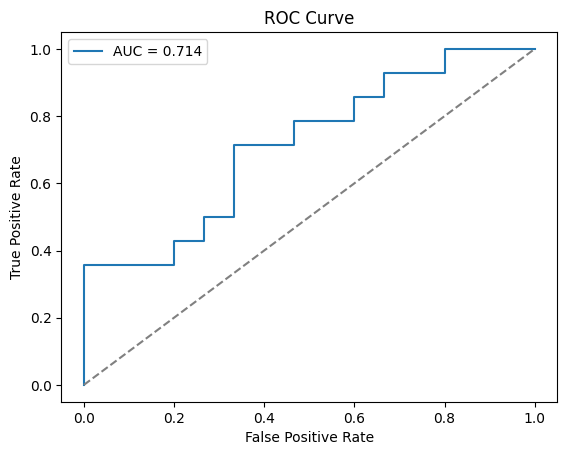

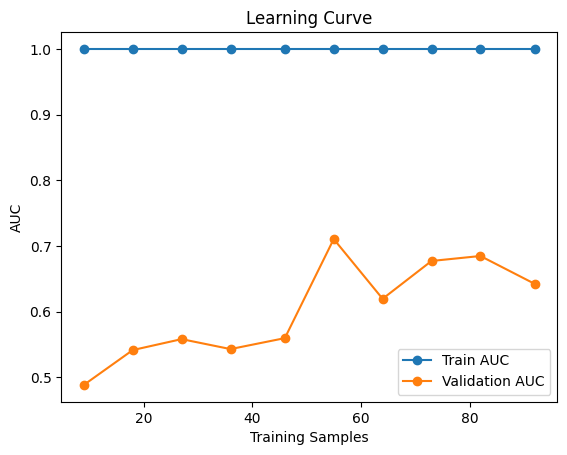

In [147]:
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# ---- Step 1: Train/Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    fusion_features, y, test_size=0.2, stratify=y, random_state=42
)

# ---- Step 2: Initialize Model ----
model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

# ---- Step 3: Stratified K-Fold CV ----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# ---- Step 4: Fit on Full Training Data ----
model.fit(X_train, y_train)

# ---- Step 5: Evaluate on Test Set ----
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

auc_score = roc_auc_score(y_test, y_prob)
print("Test AUC:", auc_score)

# ---- Step 6: Plot ROC Curve ----
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ---- Step 7: Plot Learning Curve ----
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), shuffle=True, random_state=42
)

plt.figure()
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Train AUC')
plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', label='Validation AUC')
plt.xlabel("Training Samples")
plt.ylabel("AUC")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [148]:
X1, y1 = load_data("spiral/training")
X2, y2 = load_data("wave/training")
X3, y3 = load_data("spiral/testing")
X4, y4 = load_data("wave/testing")

X = np.concatenate([X1, X2, X3, X4])
y = np.concatenate([y1, y2, y3, y4])

print("Total Data:", X.shape)

Total Data: (204, 224, 224, 3)


In [149]:
def extract_extra_features(images):
    feats = []

    for img in images:
        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)

        # Edge density
        edges = cv2.Canny(gray, 50, 150)
        edge_density = np.sum(edges) / edges.size

        # Smoothness (tremor indicator)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        smoothness = np.var(laplacian)

        feats.append([edge_density, smoothness])

    return np.array(feats)

In [151]:
X1, y1 = load_data("spiral/training")
X2, y2 = load_data("wave/training")
X3, y3 = load_data("spiral/testing")
X4, y4 = load_data("wave/testing")

X = np.concatenate([X1, X2, X3, X4])
y = np.concatenate([y1, y2, y3, y4])

print("Total Data:", X.shape)

Total Data: (204, 224, 224, 3)


In [152]:
X = X / 255.0

In [153]:
deep_features = feature_extractor.predict(X)
print(deep_features.shape)

7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step
(204, 1280)


In [154]:
glcm_features = extract_glcm_features(X)
print(glcm_features.shape)

(204, 4)


In [155]:
extra_features = extract_extra_features(X)
print(extra_features.shape)

(204, 2)


In [156]:
fusion_features = np.concatenate([
    deep_features,
    glcm_features,
    extra_features
], axis=1)

print("Fusion shape:", fusion_features.shape)

Fusion shape: (204, 1286)


In [157]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    fusion_features, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [158]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [159]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [160]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [161]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.64      0.76      0.70        21
           1       0.69      0.55      0.61        20

    accuracy                           0.66        41
   macro avg       0.66      0.66      0.65        41
weighted avg       0.66      0.66      0.65        41

AUC: 0.7047619047619047


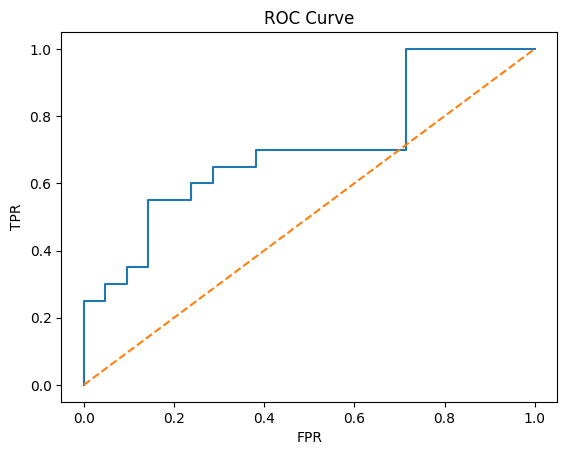

In [162]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [163]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, fusion_features, y, cv=5)
print("CV Scores:", cv_scores)
print("Mean CV:", cv_scores.mean())

CV Scores: [0.65853659 0.75609756 0.73170732 0.7804878  0.7       ]
Mean CV: 0.7253658536585366
